# ECG Signal Processing

This notebook demonstrates a basic ECG signal-processing pipeline using MIT-BIH Record 100, including preprocessing, R-peak detection, heart-rate estimation, and validation against reference annotations.

## 1. Load ECG Data

This section loads a public ECG recording from the MIT-BIH Arrhythmia Database using the WFDB library.

In [116]:
import numpy as np
import wfdb
import matplotlib.pyplot as plt

In [117]:
record = wfdb.rdrecord(
    '100',
    pn_dir='mitdb',
    sampto=int(15 * 360)
)

signal = record.p_signal[:, 0]
fs = record.fs

time = np.arange(len(signal)) / fs

print("Sampling frequency:", fs)
print("Duration:", len(signal) / fs, "seconds")

Sampling frequency: 360
Duration: 15.0 seconds


## 2. Visualize the Raw ECG

The ECG signal is plotted in the time domain to inspect its morphology.

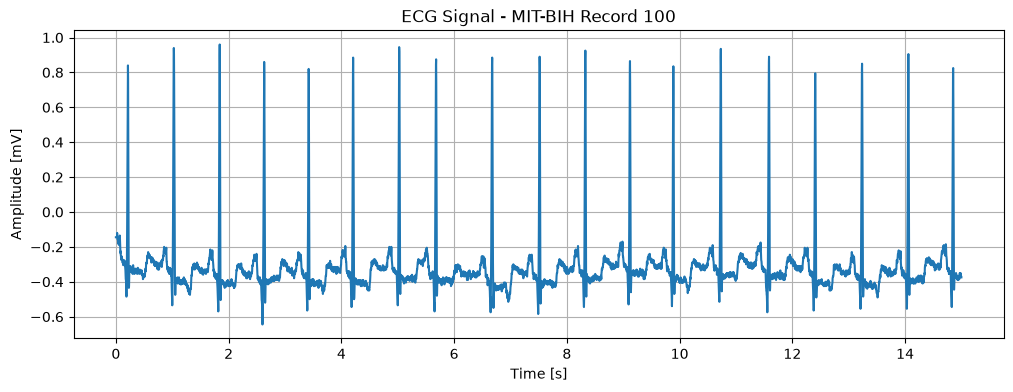

In [118]:
plt.figure(figsize=(12, 4))
plt.plot(time, signal)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude [mV]")
plt.title("ECG Signal - MIT-BIH Record 100")
plt.grid()
plt.show()

## 3. Band-pass Filtering

A fourth-order Butterworth band-pass filter is applied to reduce baseline drift and high-frequency noise while preserving the main ECG morphology.

The selected passband is:

- Low cutoff: 0.5 Hz
- High cutoff: 40 Hz
- Filter order: 4

In [119]:
from scipy.signal import butter, filtfilt, find_peaks

In [120]:
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(
        order,
        [low, high],
        btype="band"
    )

    filtered = filtfilt(b, a, signal)

    return filtered

In [121]:
filtered_signal = bandpass_filter(signal, fs)

print("Filtering completed.")

Filtering completed.


## 4. Compare Raw and Filtered ECG

The raw and filtered ECG signals are compared over the full 15-second recording to visualize the effect of preprocessing.

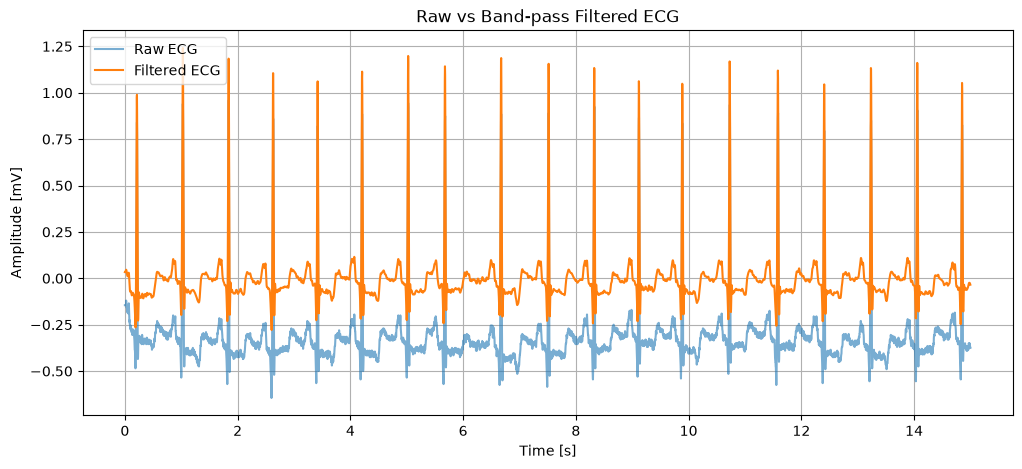

In [132]:
plt.figure(figsize=(12, 5))

plt.plot(time, signal, label="Raw ECG", alpha=0.6)
plt.plot(time, filtered_signal, label="Filtered ECG")

plt.xlabel("Time [s]")
plt.ylabel("Amplitude [mV]")
plt.title("Raw vs Band-pass Filtered ECG")
plt.legend()
plt.grid()
plt.show()

## 5. R-Peak Detection

R-peaks are detected from the filtered ECG using `scipy.signal.find_peaks`.

The detector uses:

- minimum peak height: 0.5 mV
- minimum peak distance: 0.5 s

These constraints help prevent multiple detections within the same cardiac cycle.

In [124]:
filtered_peaks, filtered_properties = find_peaks(
    filtered_signal,
    height=0.5,
    distance=int(0.5 * fs)
)

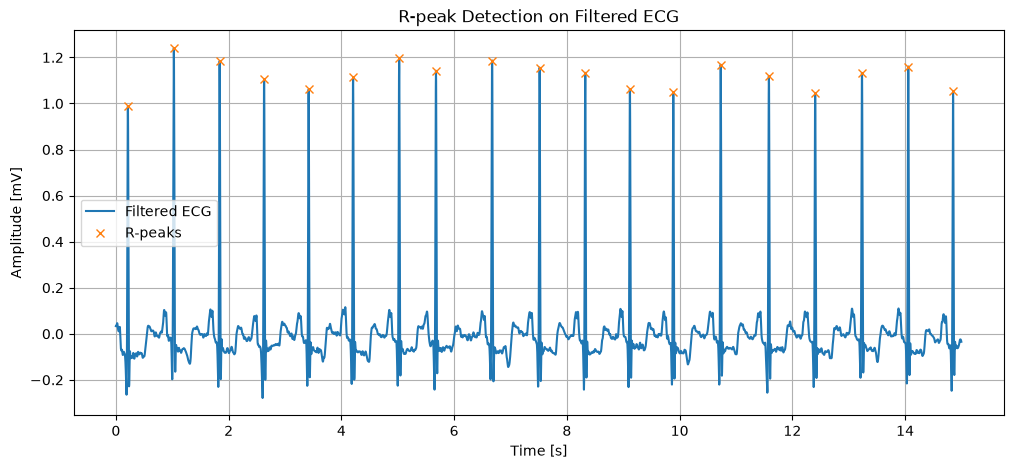

In [133]:
plt.figure(figsize=(12, 5))

plt.plot(time, filtered_signal, label="Filtered ECG")

plt.plot(
    time[filtered_peaks],
    filtered_signal[filtered_peaks],
    "x",
    label="R-peaks"
)

plt.xlabel("Time [s]")
plt.ylabel("Amplitude [mV]")
plt.title("R-peak Detection on Filtered ECG")
plt.legend()
plt.grid()
plt.show()

## 6. RR Intervals and Heart Rate

RR intervals are calculated from consecutive detected R-peaks.

The beat-to-beat heart rate is then estimated from the RR intervals and expressed in beats per minute (BPM).

In [126]:
rr_intervals_filtered = np.diff(filtered_peaks) / fs
heart_rate_filtered = 60 / rr_intervals_filtered

average_hr = np.mean(heart_rate_filtered)

print("Average heart rate:", round(average_hr, 1), "BPM")

Average heart rate: 74.2 BPM


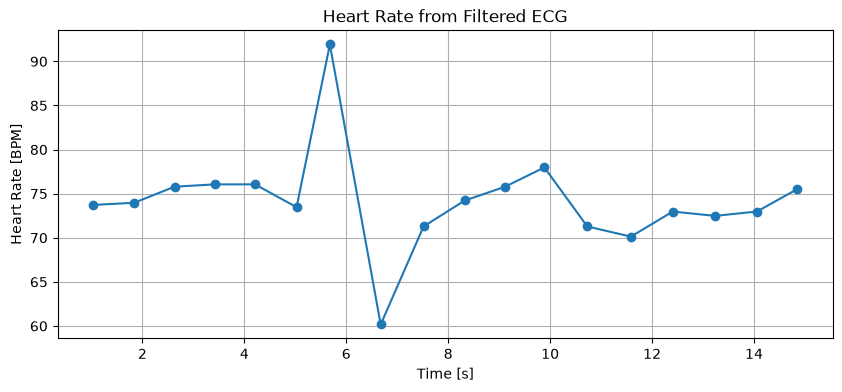

In [127]:
hr_times = time[filtered_peaks[1:]]

plt.figure(figsize=(10, 4))
plt.plot(hr_times, heart_rate_filtered, marker="o")

plt.xlabel("Time [s]")
plt.ylabel("Heart Rate [BPM]")
plt.title("Heart Rate from Filtered ECG")
plt.grid()
plt.show()

### Heart Rate Result

The ECG recording produced an average estimated heart rate of approximately **74 BPM**, with beat-to-beat variation visible throughout the analyzed segment.

## 7. Reference Beat Annotations

The reference annotations provided with MIT-BIH Record 100 are loaded using WFDB.

For the analyzed segment, beat annotations include:

- `N` — normal beat
- `A` — atrial premature beat

Non-beat markers such as `+` are excluded from the evaluation.

In [128]:
annotation = wfdb.rdann(
    '100',
    'atr',
    pn_dir='mitdb',
    sampto=len(signal)
)

In [129]:
beat_symbols = ['N', 'A']

reference_beats = np.array([
    sample
    for sample, symbol in zip(annotation.sample, annotation.symbol)
    if symbol in beat_symbols
])

print("Reference beats:", len(reference_beats))

Reference beats: 19


## 8. Comparison with Reference Beats

Detected R-peaks are compared visually with the reference beat annotations from the MIT-BIH database.

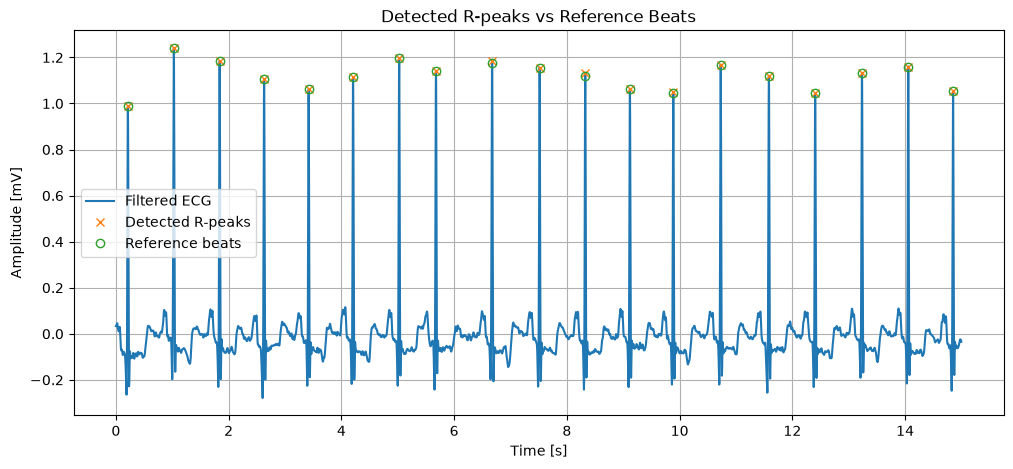

In [134]:
plt.figure(figsize=(12, 5))

plt.plot(time, filtered_signal, label="Filtered ECG")

plt.plot(
    time[filtered_peaks],
    filtered_signal[filtered_peaks],
    "x",
    label="Detected R-peaks"
)

plt.plot(
    time[reference_beats],
    filtered_signal[reference_beats],
    "o",
    fillstyle="none",
    label="Reference beats"
)

plt.xlabel("Time [s]")
plt.ylabel("Amplitude [mV]")
plt.title("Detected R-peaks vs Reference Beats")
plt.legend()
plt.grid()
plt.show()

In [131]:
tolerance = int(0.1 * fs)

true_positives = 0
matched_reference = set()

for detected in filtered_peaks:
    distances = np.abs(reference_beats - detected)

    nearest_index = np.argmin(distances)

    if distances[nearest_index] <= tolerance:
        true_positives += 1
        matched_reference.add(nearest_index)

false_positives = len(filtered_peaks) - true_positives
false_negatives = len(reference_beats) - len(matched_reference)

sensitivity = true_positives / (true_positives + false_negatives)
ppv = true_positives / (true_positives + false_positives)

print("True positives:", true_positives)
print("False positives:", false_positives)
print("False negatives:", false_negatives)
print("Sensitivity:", round(sensitivity * 100, 2), "%")
print("PPV:", round(ppv * 100, 2), "%")

True positives: 19
False positives: 0
False negatives: 0
Sensitivity: 100.0 %
PPV: 100.0 %


## 9. Evaluation Results

The R-peak detector was evaluated against the reference beat annotations provided by the MIT-BIH Arrhythmia Database.

For the analyzed **15-second segment of Record 100**:

- True positives: 19
- False positives: 0
- False negatives: 0
- Sensitivity: 100%
- Positive Predictive Value (PPV): 100%

Detected peaks were matched to reference beats using a tolerance of **100 ms**.

These results apply only to this 15-second segment and should not be interpreted as overall detector performance across the full MIT-BIH Arrhythmia Database.